# SRPO Reward Diagnostic Study

This notebook diagnoses whether the SRPO world-progress reward mechanism
produces meaningful, progress-aware reward signals.

**Experiments:**

1. **Distance & Reward Separation** — Do demos, SFT successes, SFT failures,
   and random trajectories have distinguishable distances/rewards?
2. **StandardScaler Impact** — Does applying StandardScaler before DBSCAN
   (matching siiRL production code) improve cluster quality?
3. **Reward Formula Comparison** — siiRL (min-max + 0.6 cap) vs. our
   z-score + alpha formulation.
4. **Progress Monotonicity** — Do trajectories with more task progress
   receive monotonically higher rewards?

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from vla.diagnostics.collect_trajectories import (
    CollectionConfig,
    collect_demo_trajectories,
    collect_progress_trajectories,
    collect_rollouts,
)
from vla.diagnostics.clustering import (
    ClusteringConfig,
    SOURCE_COLORS,
    SOURCE_DEMO,
    SOURCE_FAILED,
    SOURCE_RANDOM,
    SOURCE_SFT_SUCCESS,
    get_or_compute_embeddings,
    fit_umap,
    plot_panel_b,
)
from vla.diagnostics.reward_analysis import (
    build_distance_table,
    build_progress_table,
    compute_cluster_centers_raw,
    compute_cluster_centers_siirl,
    compute_progress_correlation,
    compute_siirl_rewards,
    compute_zscore_rewards,
    distances_to_nearest_center,
    plot_cosine_similarity_matrix,
    plot_distance_kde,
    plot_progress_curve,
    plot_reward_kde,
)
from vla.models.world_model import build_world_model
from vla.constants import WorldModelType
from vla.utils import get_device, seed_everything

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Configuration

In [ ]:
SEED = 42
seed_everything(SEED)
device = get_device()

SUITE = "spatial"
TASK_ID = 2
CACHE_DIR = Path("cache/reward_study")

collect_cfg = CollectionConfig(
    libero_suite=SUITE,
    task_id=TASK_ID,
    num_demos=50,
    num_rollouts=50,
    num_envs=8,
    max_steps=220,
    seed=SEED,
    cache_dir=CACHE_DIR,
)

cluster_cfg = ClusteringConfig(
    subsample_every=1,
    dbscan_min_samples=2,
    dbscan_auto_eps=True,
    dbscan_percentile=25,
    seed=SEED,
    cache_dir=CACHE_DIR,
)

print(f"Device: {device}")
print(f"Task:   {SUITE} task {TASK_ID}")
print(f"Cache:  {CACHE_DIR.resolve()}")

Device: cuda
Task:   spatial task 2
Cache:  /home/rune/vla-robotics/notebooks/cache/reward_study


## Step 1 — Collect Trajectories

All buffers are cached after first run.

In [3]:
demos = collect_demo_trajectories(collect_cfg)
sft_success, sft_failed, random_trajs = collect_rollouts(collect_cfg, device)

print(f"Demos:       {len(demos)}")
print(f"SFT success: {len(sft_success)}")
print(f"SFT failed:  {len(sft_failed)}")
print(f"Random:      {len(random_trajs)}")

2026-03-29 00:55:55,396 INFO Loaded 39 trajectories from cache/reward_study/spatial_task2_demos.pt
2026-03-29 00:55:58,417 INFO Loaded 50 trajectories from cache/reward_study/spatial_task2_sft_success.pt
2026-03-29 00:55:59,216 INFO Loaded 50 trajectories from cache/reward_study/spatial_task2_sft_failed.pt
2026-03-29 00:56:00,349 INFO Loaded 50 trajectories from cache/reward_study/spatial_task2_random_failed.pt


Demos:       39
SFT success: 50
SFT failed:  50
Random:      50


## Step 2 — Compute Embeddings (V-JEPA 2)

In [4]:
encoder = build_world_model(WorldModelType.VJEPA2, device=str(device))

emb_demo = get_or_compute_embeddings(
    demos, encoder, CACHE_DIR / "emb_demos.pt", cluster_cfg.subsample_every,
)
emb_sft_ok = get_or_compute_embeddings(
    sft_success, encoder, CACHE_DIR / "emb_sft_success.pt", cluster_cfg.subsample_every,
)
emb_sft_fail = get_or_compute_embeddings(
    sft_failed, encoder, CACHE_DIR / "emb_sft_failed.pt", cluster_cfg.subsample_every,
)
emb_random = get_or_compute_embeddings(
    random_trajs, encoder, CACHE_DIR / "emb_random.pt", cluster_cfg.subsample_every,
)

for name, emb in [("Demo", emb_demo), ("SFT ok", emb_sft_ok), ("SFT fail", emb_sft_fail), ("Random", emb_random)]:
    print(f"{name:>10s}: {emb.shape}")

2026-03-29 00:56:00,355 INFO Trying AutoModel for V-JEPA 2: facebook/vjepa2-vitg-fpc64-384-ssv2
`torch_dtype` is deprecated! Use `dtype` instead!
2026-03-29 00:56:01,151 INFO V-JEPA 2 loaded via AutoModel - embed_dim=1408
2026-03-29 00:58:01,066 INFO Saved embeddings torch.Size([39, 1408]) → cache/reward_study/emb_demos.pt
2026-03-29 01:00:45,091 INFO Saved embeddings torch.Size([50, 1408]) → cache/reward_study/emb_sft_success.pt
2026-03-29 01:03:49,626 INFO Saved embeddings torch.Size([50, 1408]) → cache/reward_study/emb_sft_failed.pt
2026-03-29 01:06:28,851 INFO Saved embeddings torch.Size([50, 1408]) → cache/reward_study/emb_random.pt


      Demo: torch.Size([39, 1408])
    SFT ok: torch.Size([50, 1408])
  SFT fail: torch.Size([50, 1408])
    Random: torch.Size([50, 1408])


In [5]:
X_demo = emb_demo.cpu().numpy()
X_sft_ok = emb_sft_ok.cpu().numpy()
X_sft_fail = emb_sft_fail.cpu().numpy()
X_random = emb_random.cpu().numpy()

X_all = np.concatenate([X_demo, X_sft_ok, X_sft_fail, X_random], axis=0)
sources = (
    [SOURCE_DEMO] * len(X_demo)
    + [SOURCE_SFT_SUCCESS] * len(X_sft_ok)
    + [SOURCE_FAILED] * len(X_sft_fail)
    + [SOURCE_RANDOM] * len(X_random)
)
print(f"Total embeddings: {X_all.shape}")

Total embeddings: (189, 1408)


---

## Experiment 1 — Distance & Reward Separation

**Hypothesis:** Successful trajectories (demos, SFT success) should cluster
tightly and have small distances to cluster centers. Failed and random
trajectories should be further away. If there's no separation, the SRPO
reward signal is not informative.

In [6]:
X_reference = np.concatenate([X_demo, X_sft_ok], axis=0)
centers_raw = compute_cluster_centers_raw(X_reference)

dist_groups_raw = {
    "Demo": distances_to_nearest_center(X_demo, centers_raw),
    "SFT Success": distances_to_nearest_center(X_sft_ok, centers_raw),
    "SFT Failed": distances_to_nearest_center(X_sft_fail, centers_raw),
    "Random": distances_to_nearest_center(X_random, centers_raw),
}

print(f"Cluster centers (raw DBSCAN): {centers_raw.shape[0]}")
print()

table_raw = build_distance_table(dist_groups_raw, reward_fn=compute_siirl_rewards)
display(table_raw.style.format(precision=4))

Cluster centers (raw DBSCAN): 10



,Group,N,Dist Mean,Dist Std,Dist Min,Dist Max,Reward Mean,Reward Std
0,Demo,39,27.1794,13.1976,12.7919,87.6589,0.5479,0.0982
1,SFT Success,50,46.0742,30.1739,10.1127,130.5095,0.4462,0.1989
2,SFT Failed,50,75.4314,21.3590,43.2006,106.9153,0.3109,0.2563
3,Random,50,93.2846,11.2770,64.9377,116.1626,0.2379,0.1966


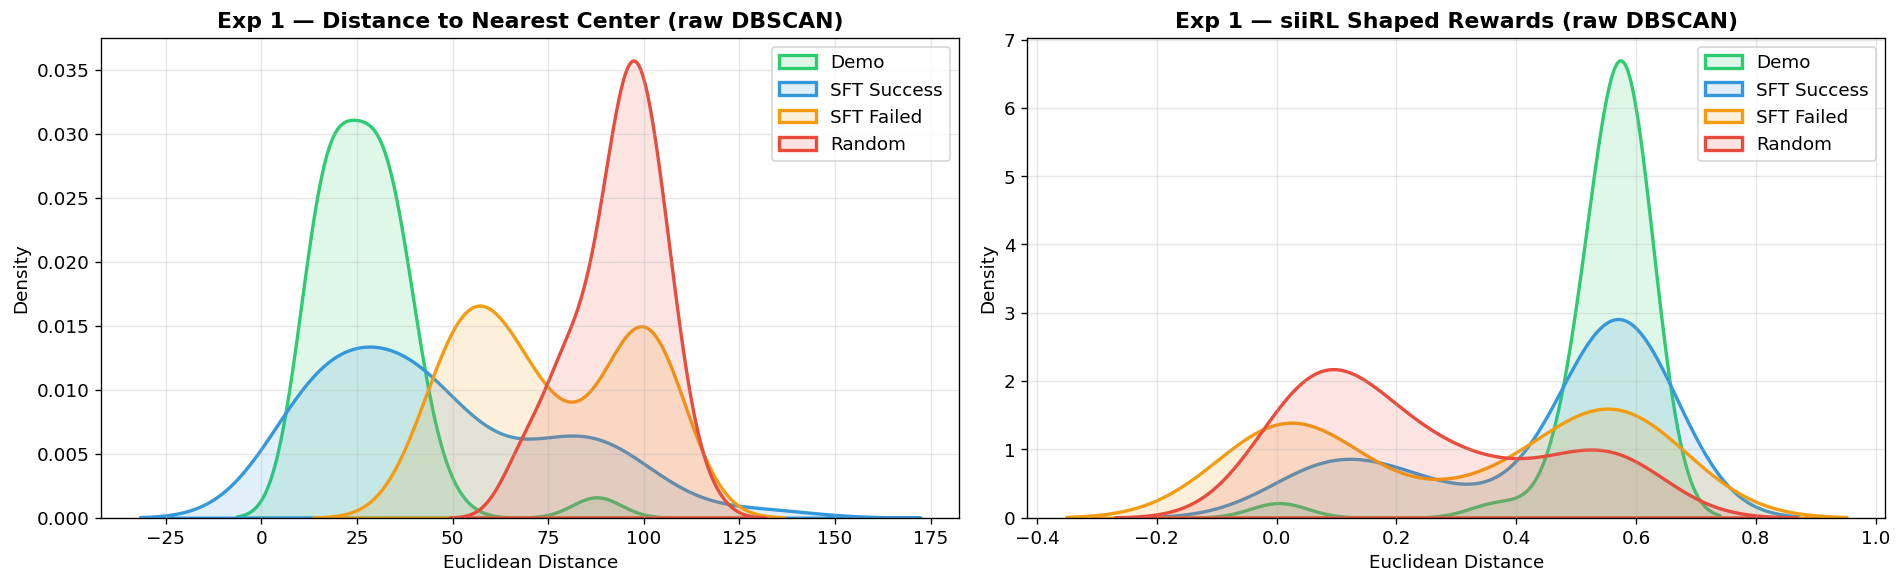

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_distance_kde(dist_groups_raw, title="Exp 1 — Distance to Nearest Center (raw DBSCAN)", ax=axes[0])
plot_reward_kde(
    dist_groups_raw,
    reward_fn=compute_siirl_rewards,
    title="Exp 1 — siiRL Shaped Rewards (raw DBSCAN)",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

### UMAP Visualisation

/home/rune/vla-robotics/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


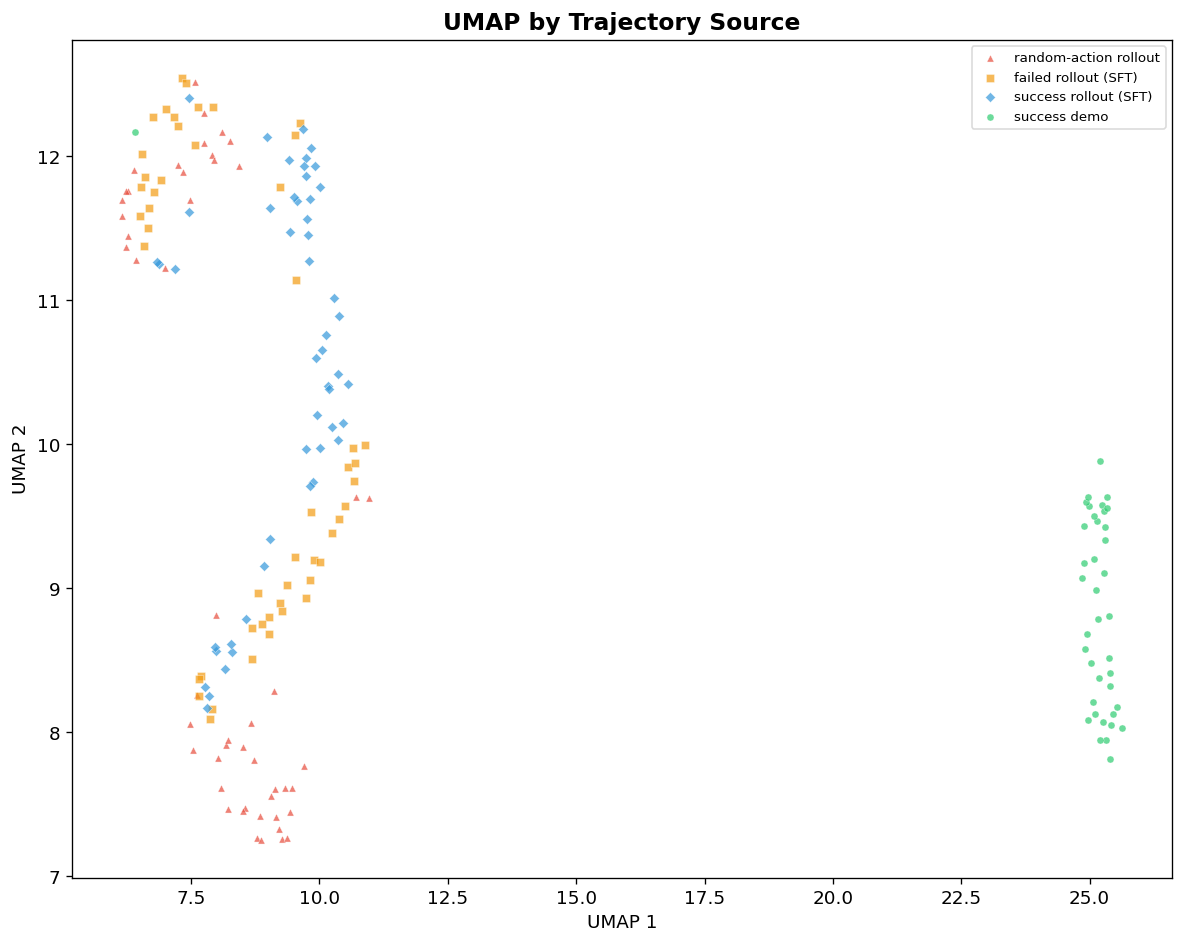

In [8]:
xy = fit_umap(X_all, cluster_cfg)

fig, ax = plt.subplots(figsize=(10, 8))
plot_panel_b(ax, xy, sources)
ax.set_title("UMAP by Trajectory Source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Cosine Similarity Between Groups

Ideally: high intra-group similarity for demos/SFT success, lower similarity
with failed/random.

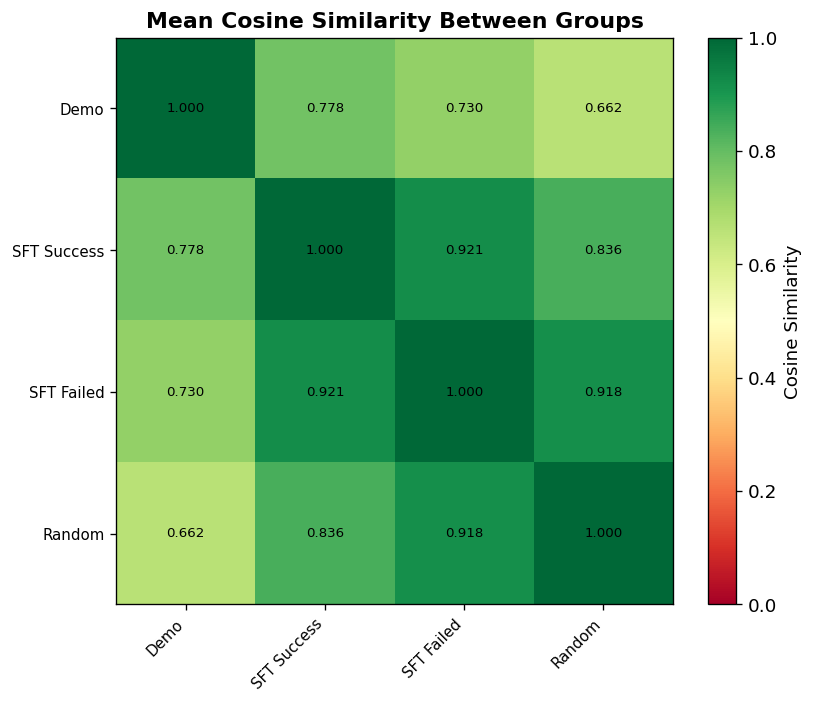

In [9]:
emb_groups = {
    "Demo": X_demo,
    "SFT Success": X_sft_ok,
    "SFT Failed": X_sft_fail,
    "Random": X_random,
}

fig, ax = plt.subplots(figsize=(7, 6))
plot_cosine_similarity_matrix(emb_groups, ax=ax)
plt.tight_layout()
plt.show()

---

## Experiment 2 — StandardScaler Impact

**Hypothesis:** siiRL applies `StandardScaler` before DBSCAN, which
normalises V-JEPA 2 embedding dimensions and improves cluster quality.
Without it, high-variance dimensions dominate, making all trajectories
look similar.

In [10]:
centers_siirl, scaler = compute_cluster_centers_siirl(X_reference)

dist_groups_siirl = {
    "Demo": distances_to_nearest_center(X_demo, centers_siirl, scaler),
    "SFT Success": distances_to_nearest_center(X_sft_ok, centers_siirl, scaler),
    "SFT Failed": distances_to_nearest_center(X_sft_fail, centers_siirl, scaler),
    "Random": distances_to_nearest_center(X_random, centers_siirl, scaler),
}

print(f"Cluster centers (siiRL method): {centers_siirl.shape[0]}")
print()

table_siirl = build_distance_table(dist_groups_siirl, reward_fn=compute_siirl_rewards)
display(table_siirl.style.format(precision=4))

Cluster centers (siiRL method): 1



,Group,N,Dist Mean,Dist Std,Dist Min,Dist Max,Reward Mean,Reward Std
0,Demo,39,33.3589,5.2471,27.3557,55.7434,0.5337,0.1254
1,SFT Success,50,39.6200,6.8572,31.1933,61.1391,0.4700,0.1846
2,SFT Failed,50,48.5487,5.2433,36.3198,56.1497,0.2096,0.2090
3,Random,50,54.7376,5.2167,44.7701,67.0624,0.3380,0.2049


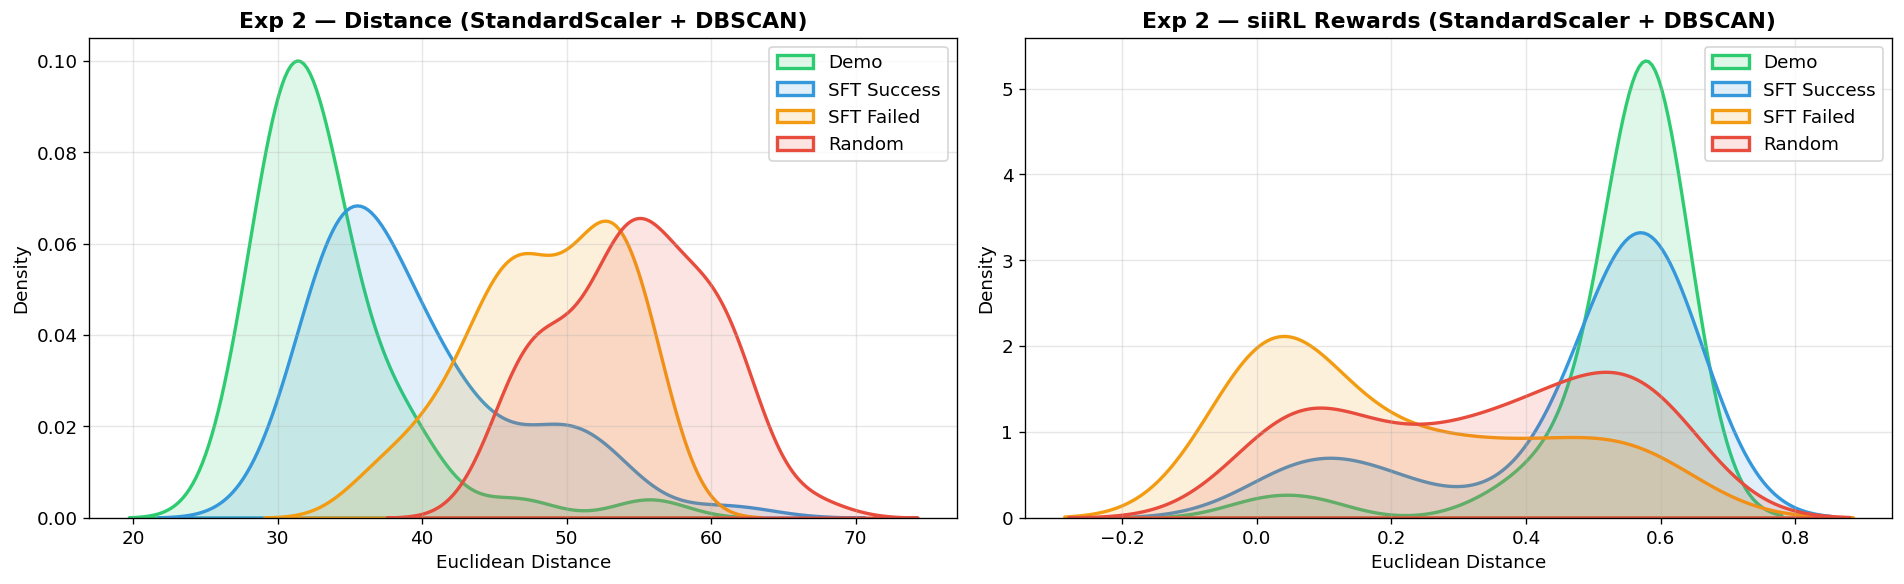

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_distance_kde(
    dist_groups_siirl,
    title="Exp 2 — Distance (StandardScaler + DBSCAN)",
    ax=axes[0],
)
plot_reward_kde(
    dist_groups_siirl,
    reward_fn=compute_siirl_rewards,
    title="Exp 2 — siiRL Rewards (StandardScaler + DBSCAN)",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

In [12]:
comparison = pd.concat(
    [
        build_distance_table(dist_groups_raw, compute_siirl_rewards).assign(Method="Raw DBSCAN"),
        build_distance_table(dist_groups_siirl, compute_siirl_rewards).assign(Method="siiRL (StandardScaler)"),
    ],
    ignore_index=True,
)
display(
    comparison[["Method", "Group", "N", "Dist Mean", "Dist Std", "Reward Mean", "Reward Std"]]
    .style.format(precision=4)
)

,Method,Group,N,Dist Mean,Dist Std,Reward Mean,Reward Std
0,Raw DBSCAN,Demo,39,27.1794,13.1976,0.5479,0.0982
1,Raw DBSCAN,SFT Success,50,46.0742,30.1739,0.4462,0.1989
2,Raw DBSCAN,SFT Failed,50,75.4314,21.3590,0.3109,0.2563
3,Raw DBSCAN,Random,50,93.2846,11.2770,0.2379,0.1966
4,siiRL (StandardScaler),Demo,39,33.3589,5.2471,0.5337,0.1254
5,siiRL (StandardScaler),SFT Success,50,39.6200,6.8572,0.4700,0.1846
6,siiRL (StandardScaler),SFT Failed,50,48.5487,5.2433,0.2096,0.2090
7,siiRL (StandardScaler),Random,50,54.7376,5.2167,0.3380,0.2049


---

## Experiment 3 — Reward Formula Comparison

**Hypothesis:** The siiRL formula (`0.6 * sigmoid(10 * (0.5 - normdist))`)
with min-max normalisation may provide better separation than our z-score
formula (`alpha * sigmoid(-z)`).

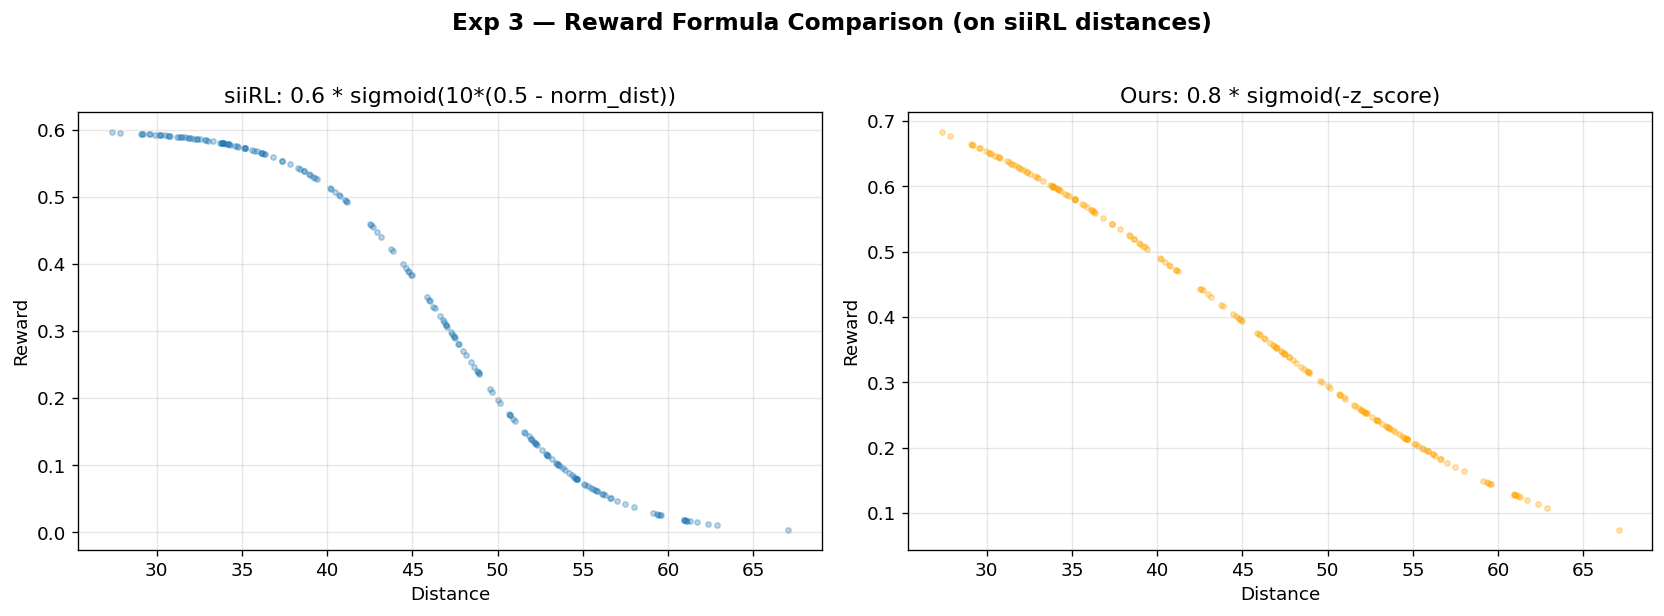

In [13]:
all_dists_siirl = np.concatenate([v for v in dist_groups_siirl.values()])

siirl_rewards = compute_siirl_rewards(all_dists_siirl)
zscore_rewards = compute_zscore_rewards(all_dists_siirl, alpha=0.8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_dists_siirl, siirl_rewards, alpha=0.3, s=10, label="siiRL")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Reward")
axes[0].set_title("siiRL: 0.6 * sigmoid(10*(0.5 - norm_dist))")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(all_dists_siirl, zscore_rewards, alpha=0.3, s=10, color="orange", label="z-score")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Reward")
axes[1].set_title("Ours: 0.8 * sigmoid(-z_score)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Exp 3 — Reward Formula Comparison (on siiRL distances)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
formula_rows = []
for name, dists in dist_groups_siirl.items():
    r_siirl = compute_siirl_rewards(dists)
    r_zscore = compute_zscore_rewards(dists, alpha=0.8)
    formula_rows.append({
        "Group": name,
        "N": len(dists),
        "siiRL Mean": r_siirl.mean(),
        "siiRL Std": r_siirl.std(),
        "z-score Mean": r_zscore.mean(),
        "z-score Std": r_zscore.std(),
        "siiRL Range": r_siirl.max() - r_siirl.min(),
        "z-score Range": r_zscore.max() - r_zscore.min(),
    })

formula_df = pd.DataFrame(formula_rows)
display(formula_df.style.format(precision=4))

,Group,N,siiRL Mean,siiRL Std,z-score Mean,z-score Std,siiRL Range,z-score Range
0,Demo,39,0.5337,0.1254,0.4157,0.1399,0.5920,0.5957
1,SFT Success,50,0.4700,0.1846,0.4110,0.1648,0.5920,0.5856
2,SFT Failed,50,0.2096,0.2090,0.3952,0.1714,0.5920,0.5772
3,Random,50,0.3380,0.2049,0.3995,0.1716,0.5920,0.6280


---

## Experiment 4 — Progress Monotonicity

**Hypothesis:** Trajectories that complete more of the task (higher progress %)
should receive higher rewards. If the V-JEPA 2 embedding captures task
progress, we expect a monotonically decreasing distance (and increasing
reward) as progress increases.

**Method:** For each demo trajectory, we replay the first N% of its recorded
actions (resetting the env first), then switch to random actions for the rest.
Progress levels: 0%, 25%, 50%, 75%, 100%.

In [15]:
PROGRESS_LEVELS = [1.0, 0.75, 0.5, 0.25, 0.0]

progress_trajs = collect_progress_trajectories(
    cfg=collect_cfg,
    reference_trajs=demos[:20],
    progress_levels=PROGRESS_LEVELS,
    source_name="demos",
)

for level in PROGRESS_LEVELS:
    trajs = progress_trajs[level]
    mean_len = np.mean([t.length for t in trajs]) if trajs else 0
    print(f"Progress {level*100:3.0f}%: {len(trajs)} trajectories, mean length {mean_len:.0f}")

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /home/rune/.cache/libero/assets


2026-03-29 01:06:44,070 INFO LiberoVecEnv created: 1 envs for task 2 in 4.5s
2026-03-29 01:06:44,070 INFO Collecting progress trajectories: level=100% from demos (20 refs)
2026-03-29 01:08:08,871 INFO Saved 20 trajectories → cache/reward_study/spatial_task2_progress_100_from_demos.pt
2026-03-29 01:08:08,872 INFO Collecting progress trajectories: level=75% from demos (20 refs)
2026-03-29 01:09:32,818 INFO Saved 20 trajectories → cache/reward_study/spatial_task2_progress_75_from_demos.pt
2026-03-29 01:09:32,819 INFO Collecting progress trajectories: level=50% from demos (20 refs)
2026-03-29 01:10:56,915 INFO Saved 20 trajectories → cache/reward_study/spatial_task2_progress_50_from_demos.pt
2026-03-29 01:10:56,916 INFO Collecting progress trajectories: level=25% from demos (20 refs)
2026-03-29 01:12:20,770 INFO Saved 20 trajectories → cache/reward_study/spatial_task2_progress_25_from_demos.pt
2026-03-29 01:12:20,770 INFO Collecting progress trajectories: level=0% from demos (20 refs)
2026

Progress 100%: 20 trajectories, mean length 220
Progress  75%: 20 trajectories, mean length 220
Progress  50%: 20 trajectories, mean length 220
Progress  25%: 20 trajectories, mean length 220
Progress   0%: 20 trajectories, mean length 220


In [16]:
progress_embs = {}
for level in PROGRESS_LEVELS:
    pct = int(level * 100)
    cache_name = CACHE_DIR / f"emb_progress_{pct}.pt"
    progress_embs[level] = get_or_compute_embeddings(
        progress_trajs[level], encoder, cache_name, cluster_cfg.subsample_every,
    )
    print(f"Progress {pct:3d}%: {progress_embs[level].shape}")

2026-03-29 01:14:49,102 INFO Saved embeddings torch.Size([20, 1408]) → cache/reward_study/emb_progress_100.pt


Progress 100%: torch.Size([20, 1408])


2026-03-29 01:15:51,363 INFO Saved embeddings torch.Size([20, 1408]) → cache/reward_study/emb_progress_75.pt


Progress  75%: torch.Size([20, 1408])


2026-03-29 01:16:53,554 INFO Saved embeddings torch.Size([20, 1408]) → cache/reward_study/emb_progress_50.pt


Progress  50%: torch.Size([20, 1408])


2026-03-29 01:17:55,265 INFO Saved embeddings torch.Size([20, 1408]) → cache/reward_study/emb_progress_25.pt


Progress  25%: torch.Size([20, 1408])


2026-03-29 01:18:56,525 INFO Saved embeddings torch.Size([20, 1408]) → cache/reward_study/emb_progress_0.pt


Progress   0%: torch.Size([20, 1408])


In [17]:
distances_per_level_raw = {}
distances_per_level_siirl = {}

for level in PROGRESS_LEVELS:
    X_prog = progress_embs[level].cpu().numpy()
    distances_per_level_raw[level] = distances_to_nearest_center(X_prog, centers_raw)
    distances_per_level_siirl[level] = distances_to_nearest_center(X_prog, centers_siirl, scaler)

print("Progress table (siiRL distances):")
progress_df = build_progress_table(PROGRESS_LEVELS, distances_per_level_siirl)
display(progress_df.style.format(precision=4))

Progress table (siiRL distances):


,Progress %,N,Dist Mean,Dist Std,siiRL Reward,z-score Reward
0,100%,20,47.1453,5.2482,0.3401,0.4025
1,75%,20,49.4253,5.2797,0.2608,0.3957
2,50%,20,49.8063,3.9039,0.1762,0.3906
3,25%,20,49.8096,4.4908,0.2319,0.3948
4,0%,20,53.8396,5.2487,0.4577,0.4089


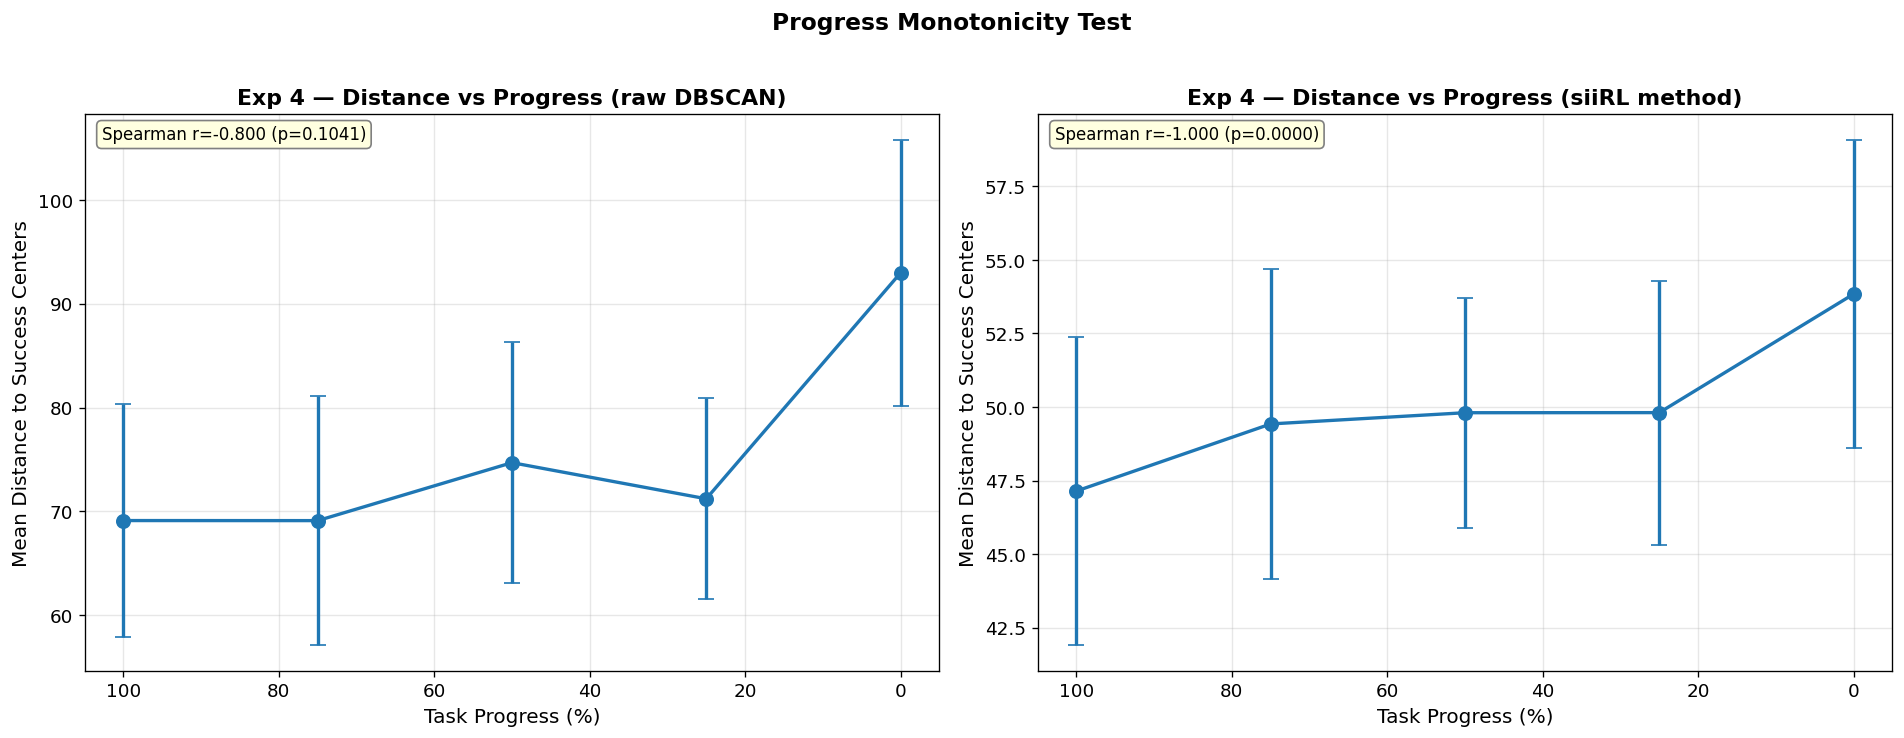

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_progress_curve(
    PROGRESS_LEVELS,
    distances_per_level_raw,
    title="Exp 4 — Distance vs Progress (raw DBSCAN)",
    ax=axes[0],
)
plot_progress_curve(
    PROGRESS_LEVELS,
    distances_per_level_siirl,
    title="Exp 4 — Distance vs Progress (siiRL method)",
    ax=axes[1],
)

plt.suptitle("Progress Monotonicity Test", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
corr_raw, pval_raw = compute_progress_correlation(PROGRESS_LEVELS, distances_per_level_raw)
corr_siirl, pval_siirl = compute_progress_correlation(PROGRESS_LEVELS, distances_per_level_siirl)

print(f"Spearman correlation (raw):   r={corr_raw:.4f}, p={pval_raw:.4f}")
print(f"Spearman correlation (siiRL): r={corr_siirl:.4f}, p={pval_siirl:.4f}")
print()
print("Expected: negative correlation (higher progress → lower distance)")

Spearman correlation (raw):   r=-0.8000, p=0.1041
Spearman correlation (siiRL): r=-1.0000, p=0.0000

Expected: negative correlation (higher progress → lower distance)


---

## Summary

Key questions to answer from the results above:

1. **Is there distance/reward separation between trajectory groups?**
   Check the KDE plots from Exp 1. If all groups overlap, the embedding
   is not capturing task-relevant information.

2. **Does StandardScaler help?**
   Compare the comparison table from Exp 2. Look for increased separation
   between success and failure groups.

3. **Which reward formula is better?**
   Compare reward ranges and standard deviations in Exp 3. The formula with
   wider dynamic range is preferable for RL.

4. **Is the progress reward monotonic?**
   Check the Spearman correlation from Exp 4. A strong negative correlation
   (r < -0.8) with low p-value confirms the reward captures task progress.